# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from model_lib import getModel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

pd.set_option('display.max_columns', None)
ohe = OneHotEncoder()
orge = OrdinalEncoder()
ss = StandardScaler()
models = getModel(200)

print(1)

1


/home/Xsemka/projects/ml_lessons/taks_linreg/task/model_lib.py:19: FutureWarning: `warn_independent_sampling` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  self.sampler = optuna.samplers.TPESampler(multivariate=True, warn_independent_sampling=False)
/home/Xsemka/projects/ml_lessons/taks_linreg/task/model_lib.py:19: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  self.sampler = optuna.samplers.TPESampler(multivariate=True, warn_independent_sampling=False)


### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [65]:
data = pd.read_csv("data.csv")
data["plans_university"] = data["plans_universitypast_failures"] // 10
data["past_failures"] = data["plans_universitypast_failures"] % 10
data.drop("plans_universitypast_failures", inplace = True, axis=1)

print(data.head())
data.info()

# print(f'{data["age"].unique()} уникальные ВОЗРАСТА')
# print(f'{data["traveltime"].unique()} уникальные тревелтайма')
# print(f'{data["studytime"].unique()} уникальные студитайма')
# print(f'{data["sex_M"].unique()} уникальные полы')
# print(f'{data["address_U"].unique()} уникальные адреса')
# print(f'{data["famsize_LE3"].unique()} уникальные размеры семей')
# print(f'{data["Pstatus_T"].unique()} уникальные семейный статусы')
# print(f'{data["nursery"].unique()} уникальные детские сады')
# print(f'{data["plans_university"].unique()} уникальные планы на универ')
# print(f'{data["past_failures"].unique()} уникальные незачёты')



   age  Medu  Fedu  traveltime  studytime  famrel  freetime  goout  Dalc  \
0   16     4     4           1          2       5         4    4.0   1.0   
1   17     4     4           1          1       5         3    4.0   1.0   
2   16     1     1           2          1       4         5    5.0   2.0   
3   18     1     2           2          1       3         4    4.0   2.0   
4   17     2     1           2          2       4         2    5.0   1.0   

   Walc  health  sex_M  address_U  famsize_LE3  Pstatus_T  nursery  \
0   2.0       5      1          1            0          1        1   
1   2.0       5      0          1            0          1        1   
2   4.0       5      1          0            1          1        1   
3   4.0       4      1          1            0          1        0   
4   2.0       5      0          0            0          1        1   

   plans_university  past_failures  
0                 1              0  
1                 1              0  
2          

### Задача 2: пропуски в данных 
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [66]:
# data.fillna(0, inplace=True)

### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [67]:
# data = ss.fit_transform(data)

### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [68]:
# scores = pd.read_csv("scores.csv", header=None)
# y = scores / 10
# x = data
# x = ss.fit_transform(x)

# print(x.shape , y.shape)

# x_train, x_test, y_train, y_test = train_test_split(x ,y, train_size=0.7)
# # model = models.random_forest_regressor(x_train, x_test, y_train, y_test)
# model = LinearRegression(n_jobs=-1)
# model.fit(x_train, y_train)

# score = cross_val_score(model, x, y, cv=4)

# print(score)

### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [69]:
scores = pd.read_csv("scores.csv", header=None)
scores.columns = ["scores"]

attendance = pd.read_csv("attendance.csv", sep = ";")
attendance.replace("+", 1, inplace= True)
attendance.fillna(0, inplace= True)
attendance = attendance.mean(axis=1)
attendance.columns = ["attendance"]

school_support = pd.read_csv("school_support.txt", sep = "\t", header=None)
school_support.columns = ["school_support"]

print(type(data), type(attendance), type(school_support))

data.reset_index()
data = pd.concat([data, attendance, school_support, scores], axis = 1)
data.fillna(0, inplace=True)
data.drop_duplicates()
data.columns = map(str, data.columns)


<class 'pandas.DataFrame'> <class 'pandas.Series'> <class 'pandas.DataFrame'>


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

In [70]:
raw_data = data
data = data[(data["age"] > 23) | (data["traveltime"].isin({1, 2, 3, 4})) | (data["past_failures"].isin({1, 2, 3, 4})) | (data["plans_university"].isin({1, -1}))]

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

In [71]:
import sklearn
from sklearn import linear_model

x = data.drop("scores", axis=1)
y = data["scores"]

x = ss.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7)

model = linear_model.LinearRegression().fit(data, scores)
prediction = model.predict(raw_data)
error = (prediction - scores)**2

range(0, 649)
           scores
0    2.646413e-23
1    4.543839e-26
2    1.793382e-23
3    2.355168e-23
4    2.480941e-23
..            ...
644  1.068307e-25
645  1.068307e-25
646  1.212195e-25
647  1.115260e-25
648  1.068307e-25

[649 rows x 1 columns]


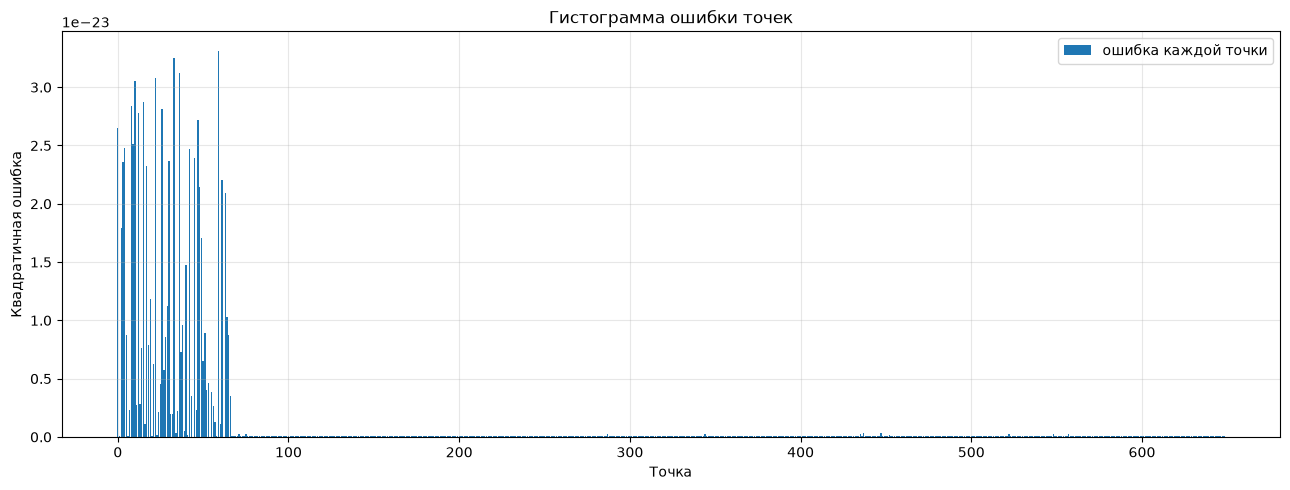

In [72]:
import matplotlib.pyplot as plt

print(range(len(x)))
print(error)

figure, axis = plt.subplots(1, 1, figsize=(13, 5))
axis.bar(list(range(len(x))), error["scores"], label = "ошибка каждой точки")
axis.set_title("Гистограмма ошибки точек")
axis.set_xlabel("Точка")
axis.set_ylabel("Квадратичная ошибка")
axis.grid(True, alpha=0.3)
axis.legend()

figure.tight_layout()
plt.show()



### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных. 

In [ ]:
score = np.mean(error["scores"])

x = raw_data.drop("scores", axis=1)
y = data["scores"]

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7)

raw_model = linear_model.LinearRegression().fit(x_train, y_train)
raw_pred = raw_model.predict(x_test)
raw_score = mean_squared_error(y_test, raw_pred)

print(score, raw_score)

#слева нормально обученная модель, справа на сырых данных, без добавок из остальных файлов

1.2980260175801199e-24 289.65726540130726
